In [1]:
!pip install celmech

In [2]:
import numpy as np
import rebound
import celmech as cm
from celmech import Poincare, PoincareHamiltonian
from scipy import signal
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [4]:
#helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def get_freq_of_peri(alpha,n_jup,n_sat):
    laplace_coeff_1 = np.pi**(-1)*quad(lambda x: np.cos(x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]
    laplace_coeff_2 = np.pi**(-1)*quad(lambda x: np.cos(2*x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]

    A_11 = n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_1
    A_22 = n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_1
    A_12 = -n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_2
    A_21 = -n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_2

    sols = np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21])
    g_1 = sols[0]
    g_2 = sols[1]

    print(np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21]))
    return g_1,g_2  


## Sanity Checks Against Numercial Analysis for First Order Secular and MM Resonance

[3.55301323e-05 3.82544932e-06]


/home/miaed/miniconda3/envs/jupyter-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


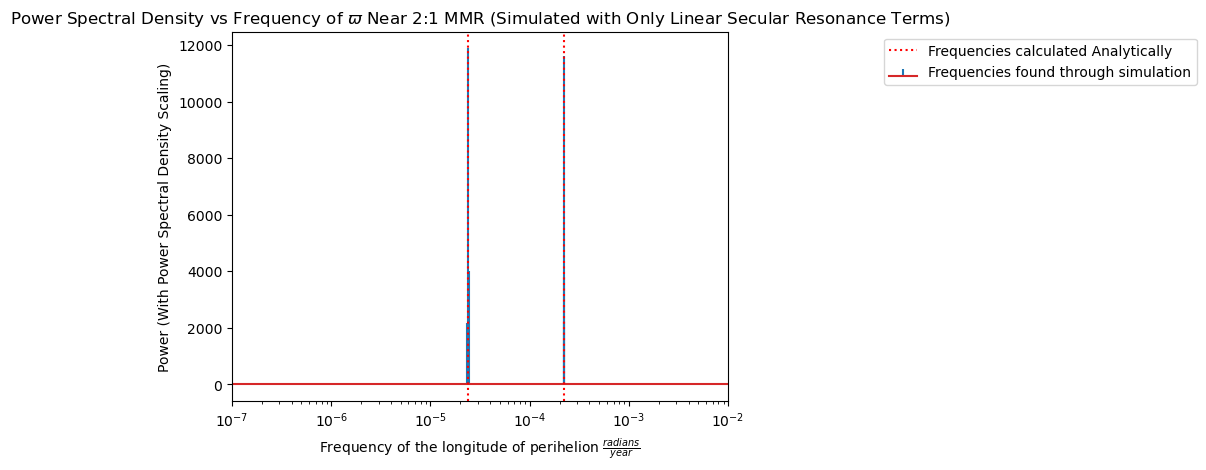

In [31]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)

for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    long_peri_j[i] = pham.state.particles[1].pomega
    e_j[i] = pham.state.particles[1].e


f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = 'Frequencies calculated Analytically')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ Near 2:1 MMR (Simulated with Only Linear Secular Resonance Terms)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

In [30]:
print(long_peri_sat)
print(pham.H_params) 

[1.56718036 1.57897895 1.59075342 ... 2.13825497 2.15017741 2.16208536]
{G: 1.0, mu1: np.float64(0.0009935903962547195), m1: np.float64(0.0009945786), M1: np.float64(1.0009945786), \Lambda_{1,0}: np.float64(0.0023522794299155967), a_{1,0}: np.float64(5.59926891881355), \alpha_{1,2}: np.float64(0.6282596315668357), mu2: np.float64(0.00028575532055643806), m2: np.float64(0.000285837), M2: np.float64(1.000285837), \Lambda_{2,0}: np.float64(0.0008532031901639505), a_{2,0}: np.float64(8.912348712982503), C_{(0,0,0,0,0,0)}^{(0,0,0,1),(0,0)}(\alpha_{1,2}): 0.382936998527643, C_{(0,0,0,0,0,0)}^{(0,0,1,0),(0,0)}(\alpha_{1,2}): 0.382936998527643, C_{(0,0,0,0,0,0)}^{(0,1,0,0),(0,0)}(\alpha_{1,2}): -1.53174799411058, C_{(0,0,0,0,0,0)}^{(1,0,0,0),(0,0)}(\alpha_{1,2}): -1.53174799411058, C_{(0,0,-1,1,0,0)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}): -0.567406752948394, C_{(0,0,0,0,-1,1)}^{(0,0,0,0),(0,0)}(\alpha_{1,2}): 3.06349598822116}


In [7]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
lambda_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
lambda_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

cm_vals = pvars.particles
for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    lambda_sat[i] = pham.state.particles[2].l
    long_peri_j[i] = pham.state.particles[1].pomega
    lambda_j[i] = pham.state.particles[1].l

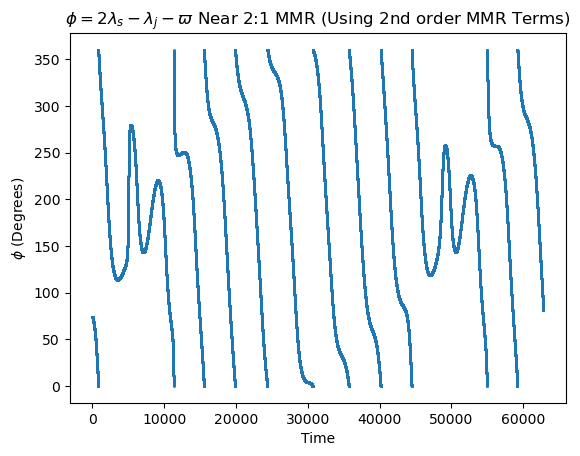

In [8]:
phi = 2*lambda_sat - lambda_j - long_peri_sat
phi = (phi) % (2 * np.pi)
plt.scatter(times,np.degrees(phi), s = 1)
plt.ylabel(r'$\phi$ (Degrees)')
plt.xlabel(r"Time")
plt.title(r'$\phi = 2\lambda_s - \lambda_j - \varpi$ Near 2:1 MMR (Using 2nd order MMR Terms)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

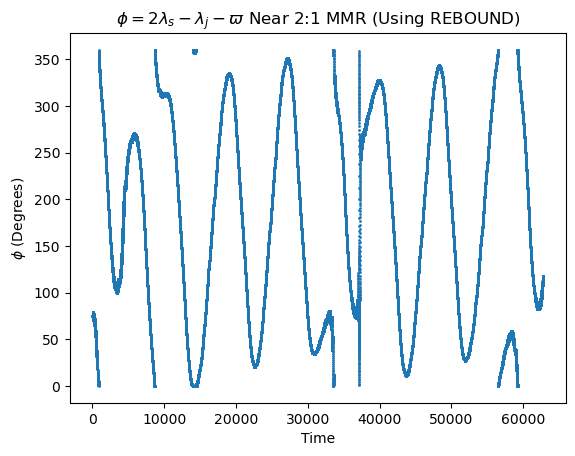

In [5]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
lambda_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
lambda_j = np.zeros(len(times))


for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    lambda_sat[i] = sim.particles[2].l
    long_peri_j[i] = sim.particles[1].pomega
    lambda_j[i] = sim.particles[1].l

phi = 2*lambda_sat - lambda_j - long_peri_sat
phi = (phi) % (2 * np.pi)
plt.scatter(times,np.degrees(phi), s = 1)
plt.ylabel(r'$\phi$ (Degrees)')
plt.xlabel(r"Time")
plt.title(r'$\phi = 2\lambda_s - \lambda_j - \varpi$ Near 2:1 MMR (Using REBOUND)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

In [15]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
lambda_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
lambda_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

cm_vals = pvars.particles
for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    lambda_sat[i] = pham.state.particles[2].l
    long_peri_j[i] = pham.state.particles[1].pomega
    lambda_j[i] = pham.state.particles[1].l

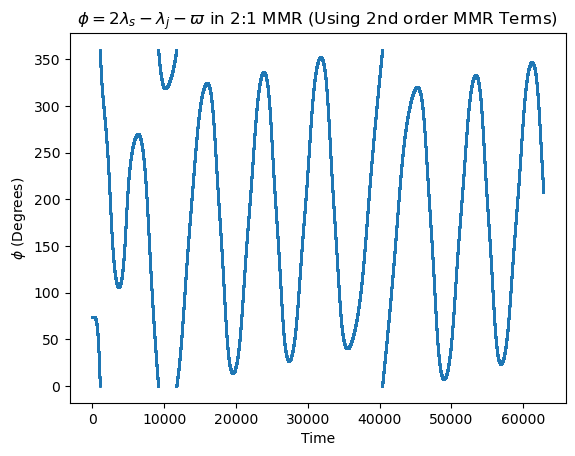

In [21]:
phi = 2*lambda_sat - lambda_j - long_peri_sat
phi = (phi) % (2 * np.pi)
plt.scatter(times,np.degrees(phi), s = 1)
plt.ylabel(r'$\phi$ (Degrees)')
plt.xlabel(r"Time")
plt.title(r'$\phi = 2\lambda_s - \lambda_j - \varpi$ in 2:1 MMR (Using 2nd order MMR Terms)')
#plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

In [33]:
pham.H

                                                               ⎛η₁⋅sin(λ₁ - 2⋅ ↪
  C_{(2,-1,-1,0,0,0)}_{1,2})__{(0,0,0,0),(0,0)}(\alpha⋅G⋅m₁⋅m₂⋅⎜────────────── ↪
                                                               ⎜  ____________ ↪
                                                               ⎝╲╱ \Lambda_{1, ↪
- ──────────────────────────────────────────────────────────────────────────── ↪
                                                a_{2,0}                        ↪
                                                                               ↪

↪ λ₂)   κ₁⋅cos(λ₁ - 2⋅λ₂)⎞                                                     ↪
↪ ─── + ─────────────────⎟   C_{(2,-1,0,-1,0,0)}_{1,2})__{(0,0,0,0),(0,0)}(\al ↪
↪ ___     _______________⎟                                                     ↪
↪ 0}    ╲╱ \Lambda_{1,0} ⎠                                                     ↪
↪ ──────────────────────── - ───────────────────────────────────────────────── ↪
↪                          

## Using both Secular and MM Resonance Terms To Model Today's 5:2 Resonance

In [48]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.202545,e=0.0474622,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=9.554841,e=0.0575481,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
pham_long_peri_sat = np.zeros(len(times))
pham_e_sat = np.zeros(len(times))

sim_long_peri_sat = np.zeros(len(times))
sim_e_sat = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(p=5,q=2,indexIn=1, indexOut=2, max_order=2)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)

cm_vals = pvars.particles
for i in range(len(times)):
    sim.integrate(times[i])
    pham.integrate(times[i])
    pham_long_peri_sat[i] = pham.state.particles[2].pomega
    pham_e_sat[i] = pham.state.particles[2].e
    sim_long_peri_sat[i] = pham.state.particles[2].pomega
    sim_e_sat[i] = pham.state.particles[2].e

/home/miaed/miniconda3/envs/jupyter-env/lib/python3.13/site-packages/scipy/integrate/_ode.py:438: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


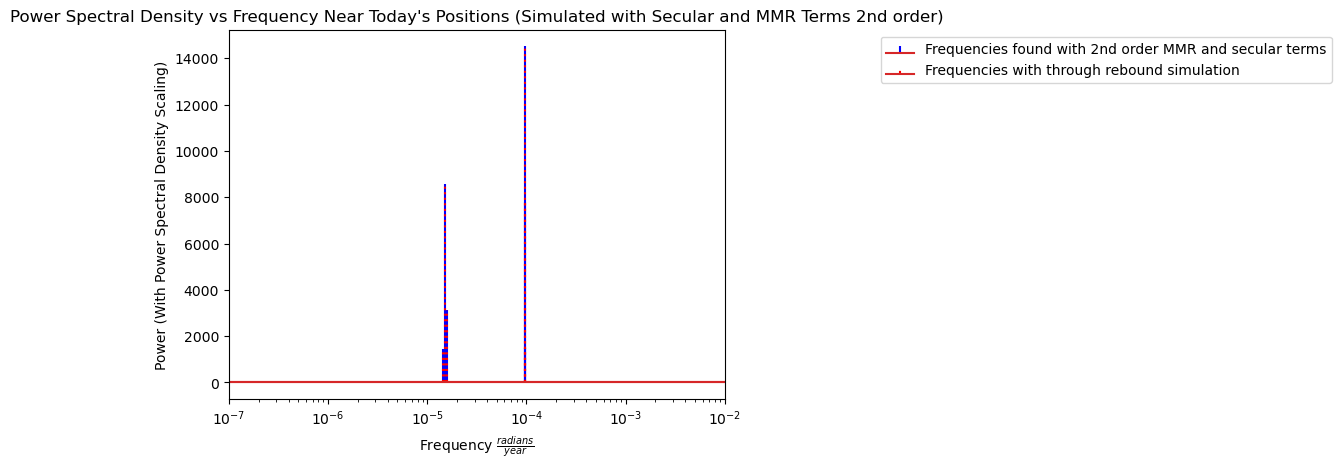

In [53]:
pham_f,pham_pxx = pomega_ft(times, pham_long_peri_sat, pham_e_sat)
wim_f,sim_pxx = pomega_ft(times, sim_long_peri_sat, sim_e_sat)

plt.stem(pham_f*2*np.pi,pham_pxx,markerfmt = "none",label = 'Frequencies found with 2nd order MMR and secular terms', linefmt = 'b-')
plt.stem(pham_f*2*np.pi,pham_pxx,markerfmt = "none",label = 'Frequencies with through rebound simulation', linefmt = 'r:')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title('Power Spectral Density vs Frequency Near Today\'s Positions (Simulated with Secular and MMR Terms 2nd order)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

[3.55301323e-05 3.82544932e-06]


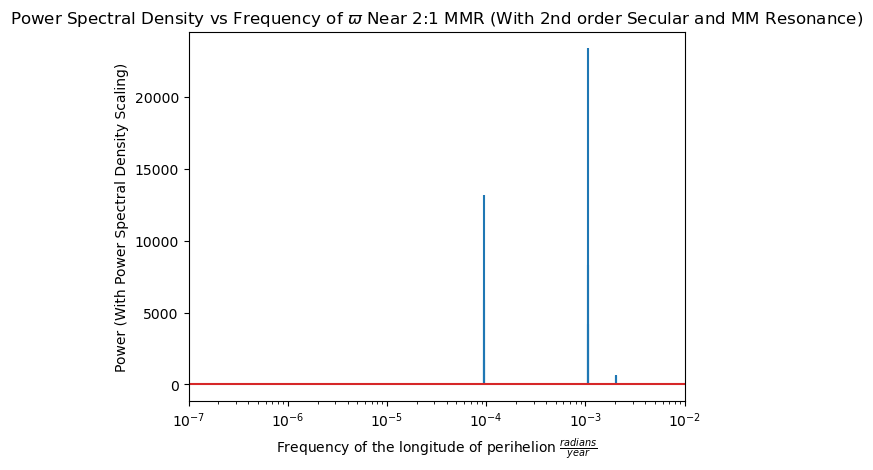

In [53]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

for i in range(len(times)):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    long_peri_j[i] = pham.state.particles[1].pomega
    e_j[i] = pham.state.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ Near 2:1 MMR (With 2nd order Secular and MM Resonance)')
plt.show()